In [1]:
!pip install torchview torchmetrics tqdm seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.0 MB/s eta 0:00:00


In [30]:
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics
from torchview import draw_graph
from statsmodels.tsa.stattools import adfuller
import statsmodels.tsa.api as sm_ts_api
import statsmodels.api as sm_api
from tqdm import tqdm

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device=}")

device='cpu'


In [32]:
dataset = pd.read_csv("/home/zorinep/ml/notebooks/myself-ml-challenge/data/datasets/train_1995-2018.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' +
    dataset['Decimal Day'].astype(str) +
    ' ' +
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
dataset = dataset[cols]
dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [33]:
fill_values = {
    "Bz_GSM": 999.9,
    "By_GSM": 999.9,
    "Bx_GSE": 999.9,
    "Kp": 99,
    "f10.7": 999.9,
    "AL": 99999,
    "AU": 99999,
    "T_proton": 9999999.,
    "Np_density": 999.9,
    "V_plasma": 9999.,
    "V_Long_GSE": 999.9,
    "V_Lat_GSE": 999.9,
    "Dst": 99999,
    "AE": 9999,
}
for col in dataset.drop(columns=["datetime"]).columns:
    dataset[col] = dataset[col].replace(fill_values[col], np.nan)

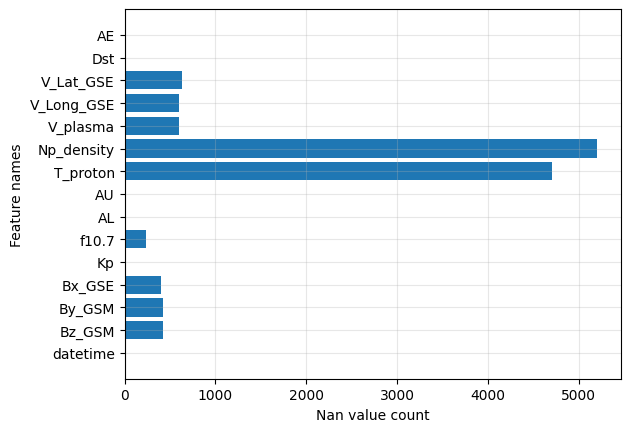

In [36]:
nan_counter = dataset.isna().sum()
plt.barh(nan_counter.index, nan_counter.values)
plt.xlabel("Nan value count")
plt.ylabel("Feature names")
plt.grid(alpha=0.3)
plt.show()

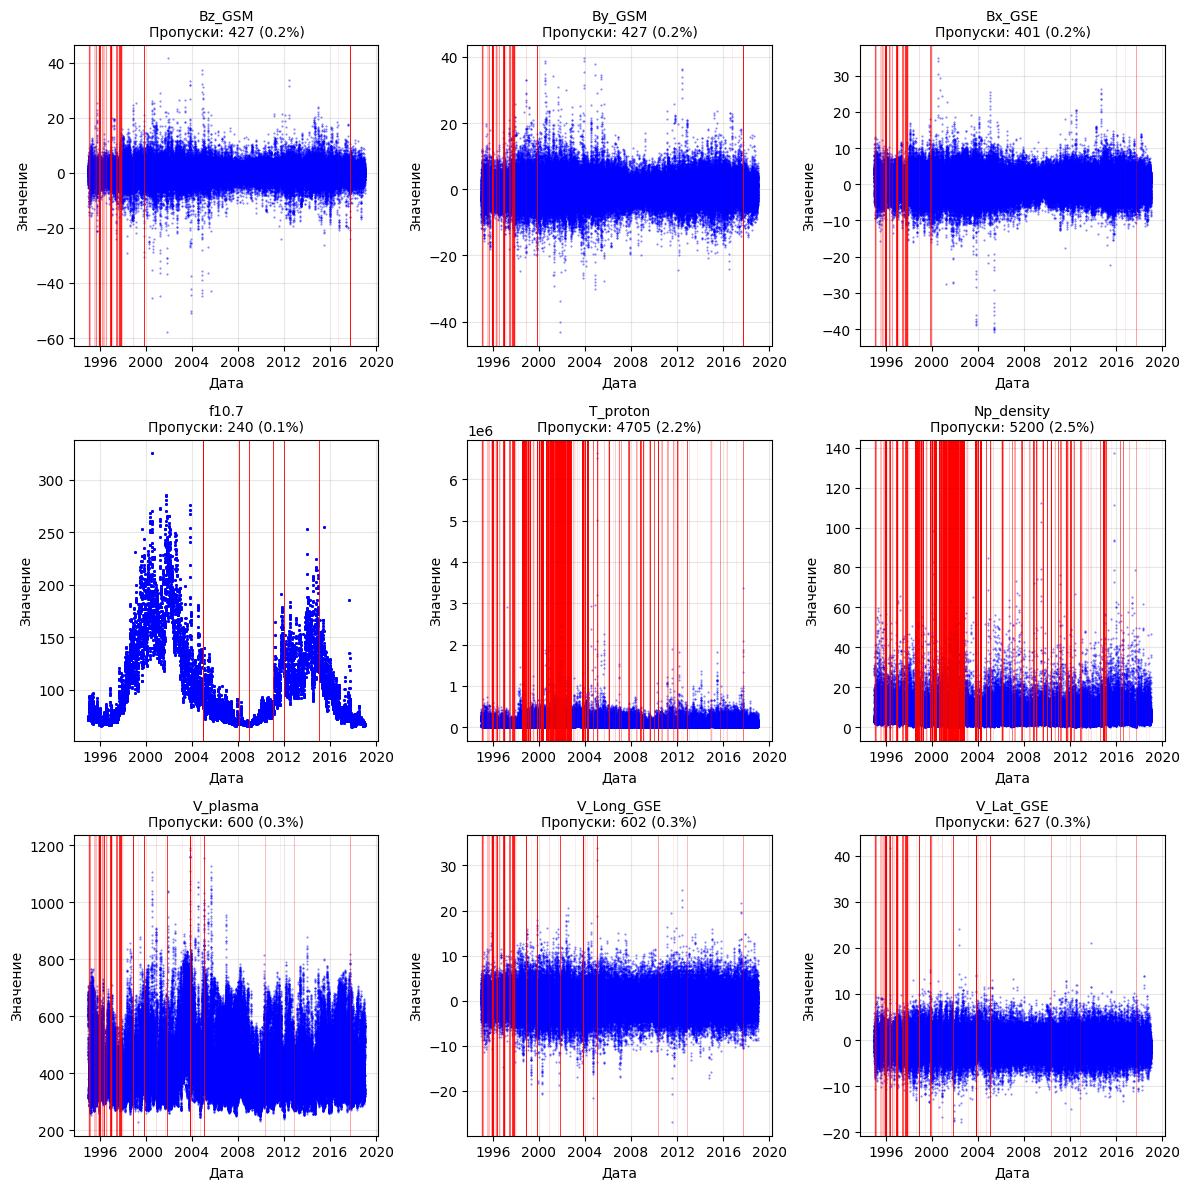

In [50]:
_, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

nan_cols = []
for k, v in nan_counter.items():
    if v != 0:
        nan_cols.append(k)

for idx, col in enumerate(nan_cols): 
    ax = axes[idx]
    mask = ~dataset[col].isna()
    ax.plot(dataset.loc[mask, 'datetime'], dataset.loc[mask, col], 'b.', markersize=1, alpha=0.5, label='Данные')

    nan_indices = dataset[dataset[col].isna()].index
    for nan_idx in nan_indices:
        ax.axvline(x=dataset.loc[nan_idx, 'datetime'], color='r', alpha=0.1, linewidth=0.5)

    ax.set_title(f'{col}\nПропуски: {dataset[col].isna().sum()} ({dataset[col].isna().sum()/len(dataset)*100:.1f}%)', fontsize=10)
    ax.set_xlabel('Дата')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   datetime    210384 non-null  datetime64[us]
 1   Bz_GSM      209957 non-null  float64       
 2   By_GSM      209957 non-null  float64       
 3   Bx_GSE      209983 non-null  float64       
 4   Kp          210384 non-null  int64         
 5   f10.7       210144 non-null  float64       
 6   AL          210384 non-null  int64         
 7   AU          210384 non-null  int64         
 8   T_proton    205679 non-null  float64       
 9   Np_density  205184 non-null  float64       
 10  V_plasma    209784 non-null  float64       
 11  V_Long_GSE  209782 non-null  float64       
 12  V_Lat_GSE   209757 non-null  float64       
 13  Dst         210384 non-null  int64         
 14  AE          210384 non-null  int64         
dtypes: datetime64[us](1), float64(9), int64(5)
memory usage: 24.1 

In [6]:
dataset.describe()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
count,210384,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,2.103840e+05,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000
mean,2006-12-31 23:30:00,1.979221,2.080122,1.874579,18.441963,109.263963,-112.295911,68.111116,3.165466e+05,30.821627,457.463357,2.709679,2.247959,-13.242243,180.439758
min,1995-01-01 00:00:00,-57.800000,-43.100000,-40.800000,0.000000,64.600000,-2452.000000,-260.000000,3.299000e+03,0.100000,228.000000,-26.900000,-17.800000,-422.000000,3.000000
25%,2000-12-31 11:45:00,-1.500000,-2.400000,-2.600000,7.000000,74.200000,-153.000000,22.000000,3.719675e+04,3.100000,354.000000,-1.700000,-2.100000,-21.000000,47.000000
50%,2006-12-31 23:30:00,0.000000,0.000000,-0.100000,17.000000,94.100000,-52.000000,44.000000,7.052950e+04,4.900000,407.000000,-0.200000,-0.700000,-10.000000,100.000000
75%,2012-12-31 11:15:00,1.400000,2.500000,2.500000,27.000000,133.100000,-21.000000,92.000000,1.307762e+05,8.100000,486.000000,1.300000,0.700000,-1.000000,245.000000
max,2018-12-31 23:00:00,999.900000,999.900000,999.900000,90.000000,999.900000,22.000000,1226.000000,9.999999e+06,999.900000,9999.000000,999.900000,999.900000,77.000000,2241.000000
std,NaN,45.103057,45.158247,43.750043,13.617466,51.154913,143.558231,68.055577,1.467536e+06,154.353747,520.345100,53.485555,54.595549,20.120794,197.759337


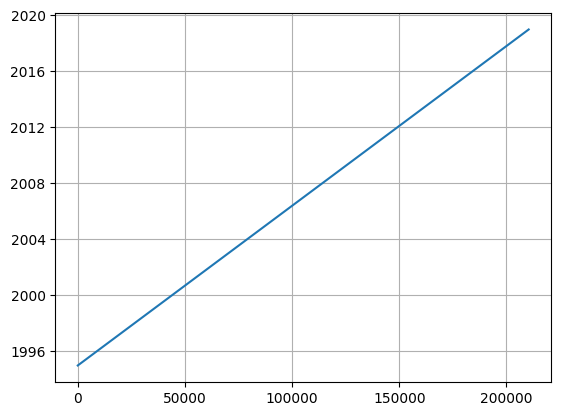

In [8]:
plt.plot(dataset["datetime"])
plt.grid();

### IMF - Interplanetary Magnetic Field (межпланетное магнитное поле)

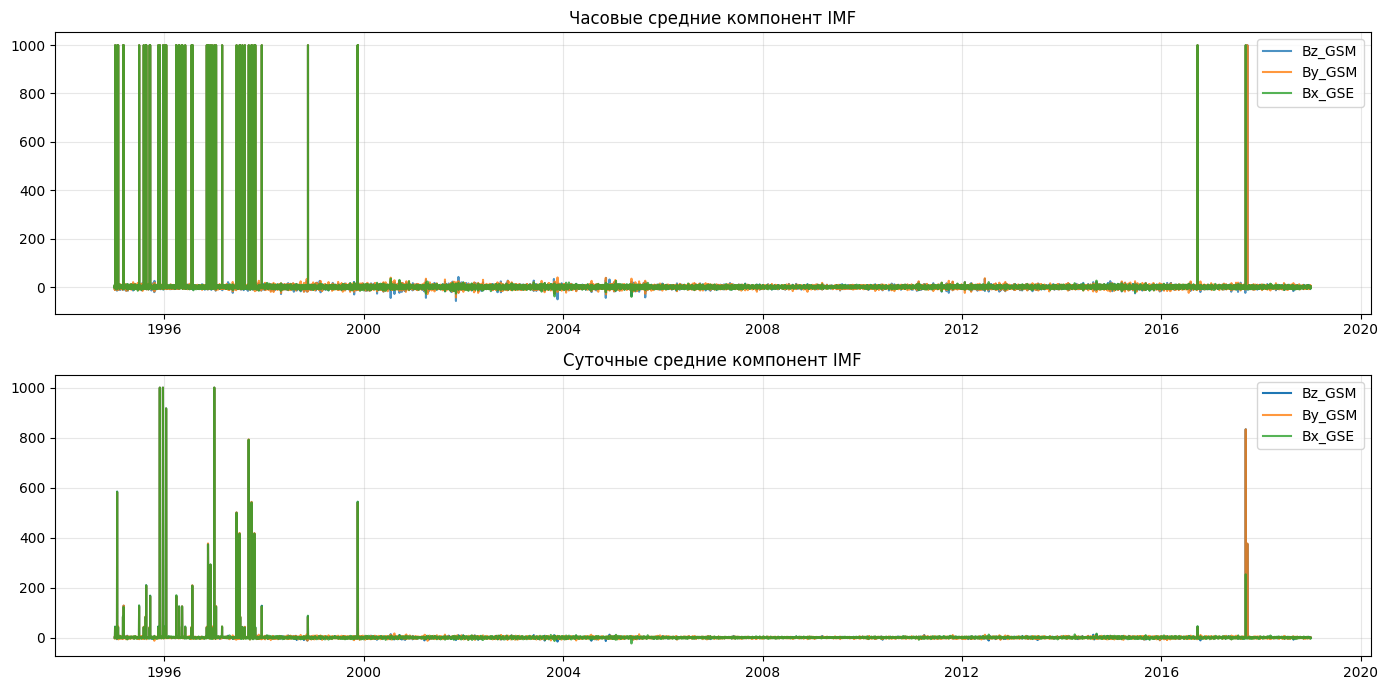

In [ ]:
_, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].set_title("Часовые средние компонент IMF")
axes[0].plot(dataset["datetime"], dataset["Bz_GSM"], alpha=0.8, label="Bz_GSM")
axes[0].plot(dataset["datetime"], dataset["By_GSM"], alpha=0.8, label="By_GSM")
axes[0].plot(dataset["datetime"], dataset["Bx_GSE"], alpha=0.8, label="Bx_GSE")
axes[0].grid(alpha=0.3)
axes[0].legend()

daily_data = dataset.set_index('datetime').resample('D').mean()
axes[1].set_title("Суточные средние компонент IMF")
axes[1].plot(daily_data.index, daily_data["Bz_GSM"], label="Bz_GSM")
axes[1].plot(daily_data.index, daily_data["By_GSM"], label="By_GSM", alpha=0.8)
axes[1].plot(daily_data.index, daily_data["Bx_GSE"], label="Bx_GSE", alpha=0.8)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
def moving_average(x, k: int):
    if not isinstance(x, pd.Series):
        x = pd.Series(x)
    return x.rolling(k).mean()

In [11]:
def make_ts_plot_with_ma(feature: pd.Series, title, label, ma_k):
    feature_ma = moving_average(feature, k=ma_k)
    plt.figure(figsize=(14, 5))
    plt.title(title)
    plt.plot(feature.index, feature, label=label)
    plt.plot(feature_ma, label="MA 120 (сезонность)")
    plt.grid(alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

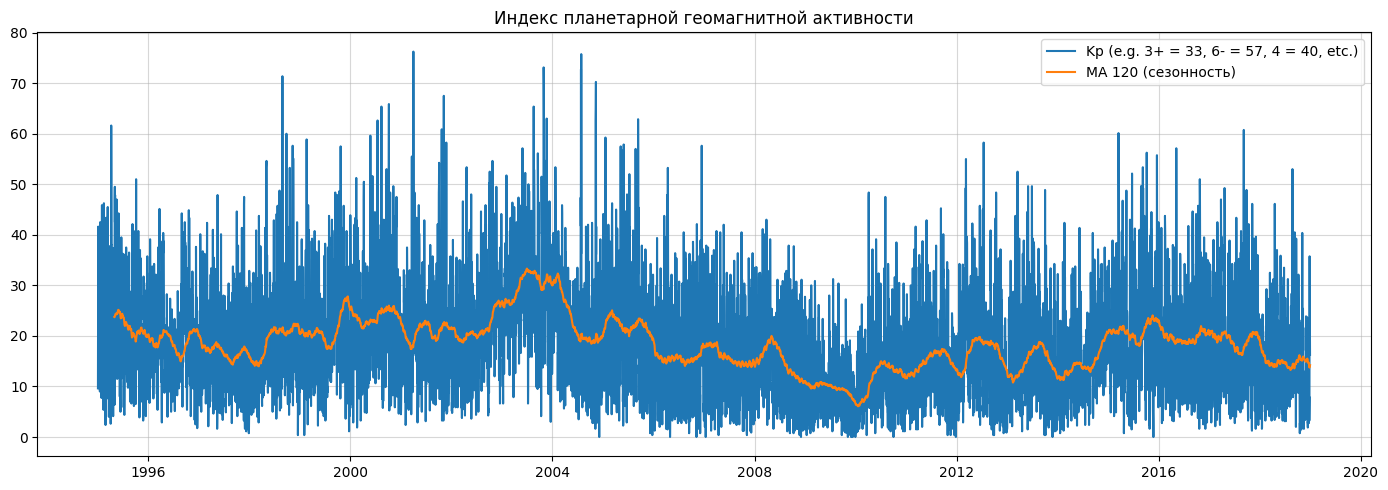

In [12]:
make_ts_plot_with_ma(
    feature=daily_data["Kp"],
    title="Индекс планетарной геомагнитной активности",
    label="Kp (e.g. 3+ = 33, 6- = 57, 4 = 40, etc.)",
    ma_k=120
)

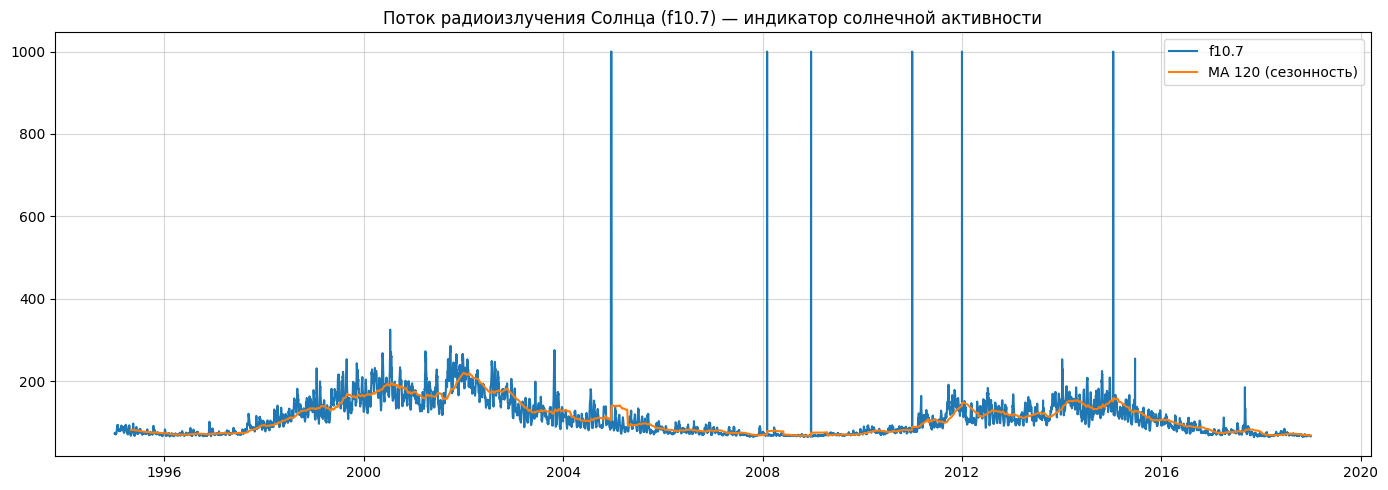

In [13]:
make_ts_plot_with_ma(
    feature=daily_data["f10.7"],
    title="Поток радиоизлучения Солнца (f10.7) — индикатор солнечной активности",
    label="f10.7",
    ma_k=120
)

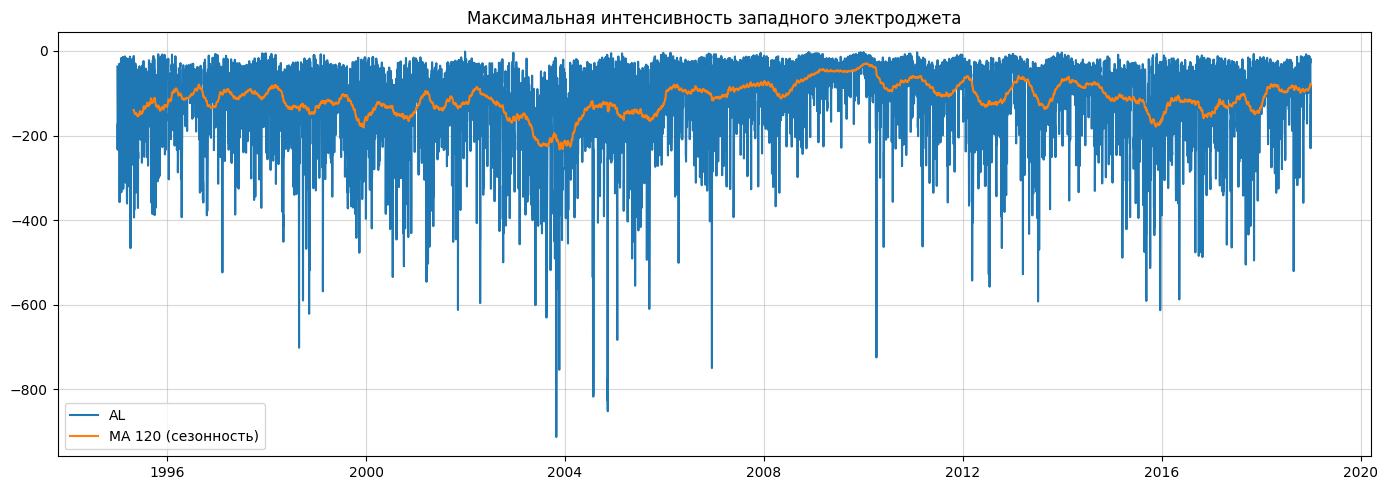

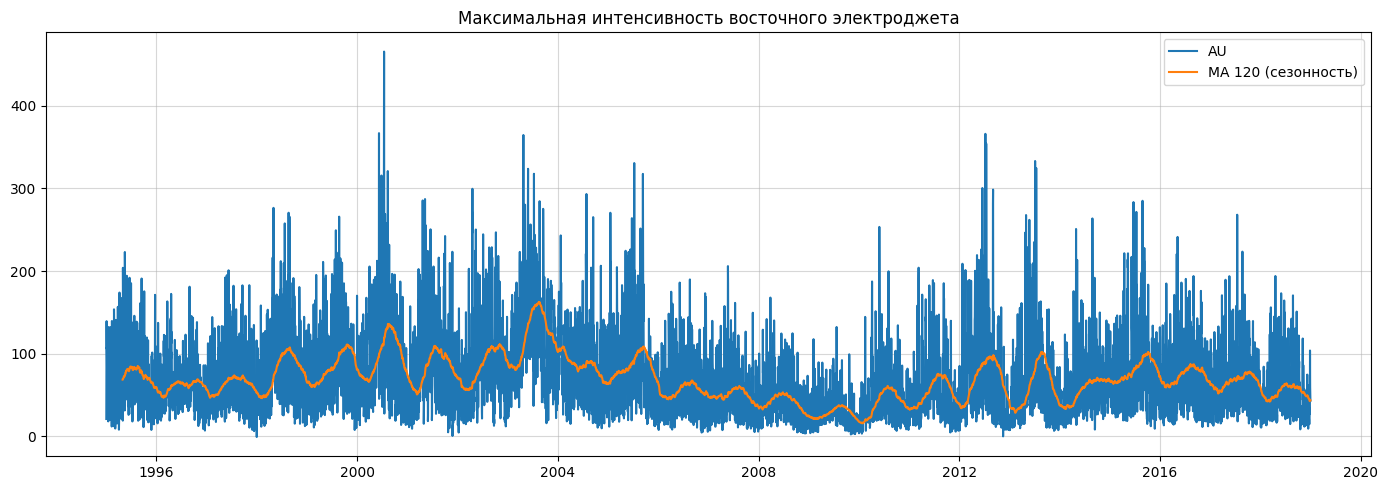

In [14]:
make_ts_plot_with_ma(
    feature=daily_data["AL"],
    title="Максимальная интенсивность западного электроджета",
    label="AL",
    ma_k=120
)
make_ts_plot_with_ma(
    feature=daily_data["AU"],
    title="Максимальная интенсивность восточного электроджета",
    label="AU",
    ma_k=120
)

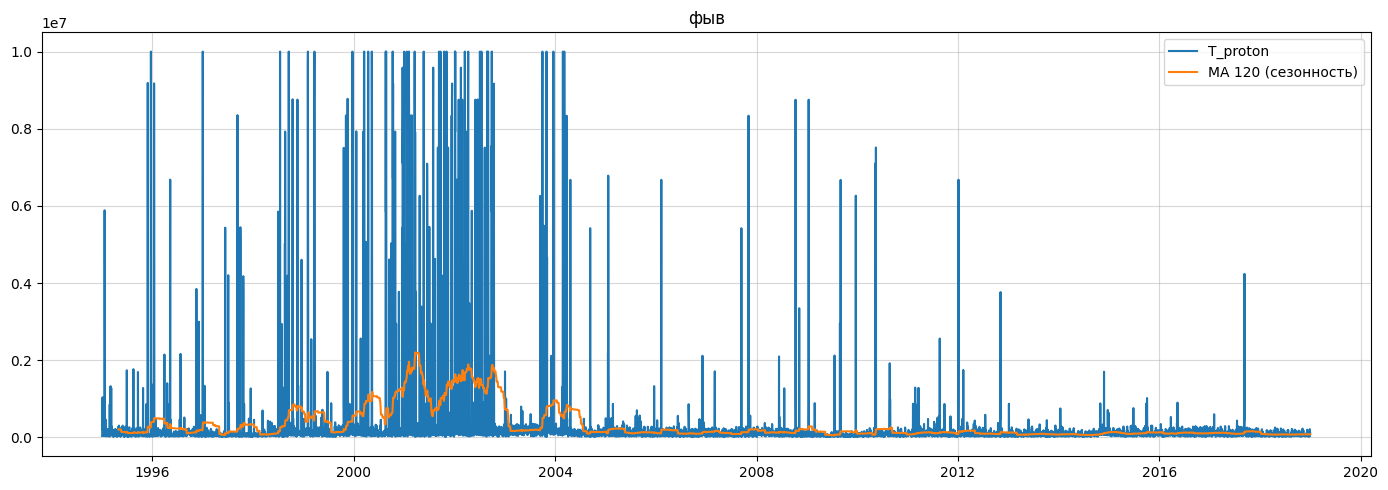

In [15]:
make_ts_plot_with_ma(
    feature=daily_data["T_proton"],
    title="фыв",
    label="T_proton",
    ma_k=120
)

### Визуализация плазменных параметров солнечного ветра

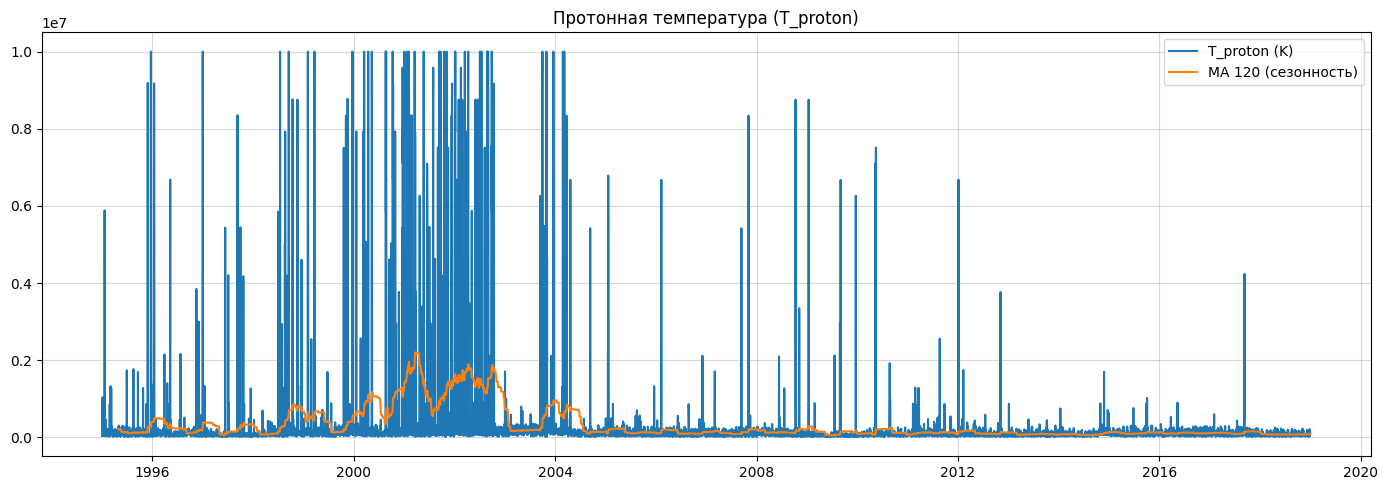

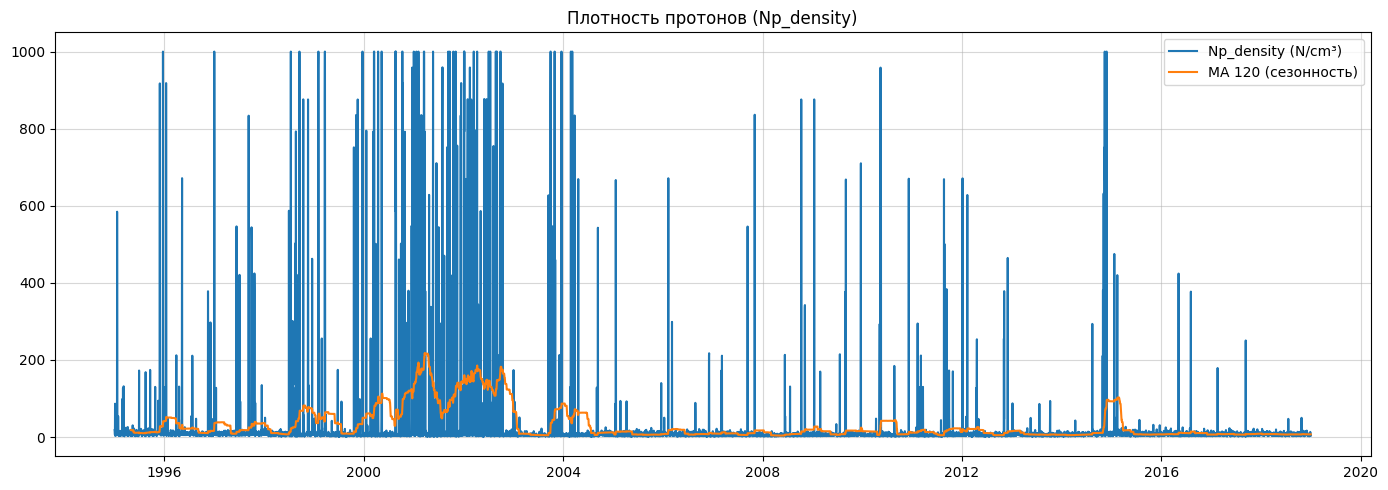

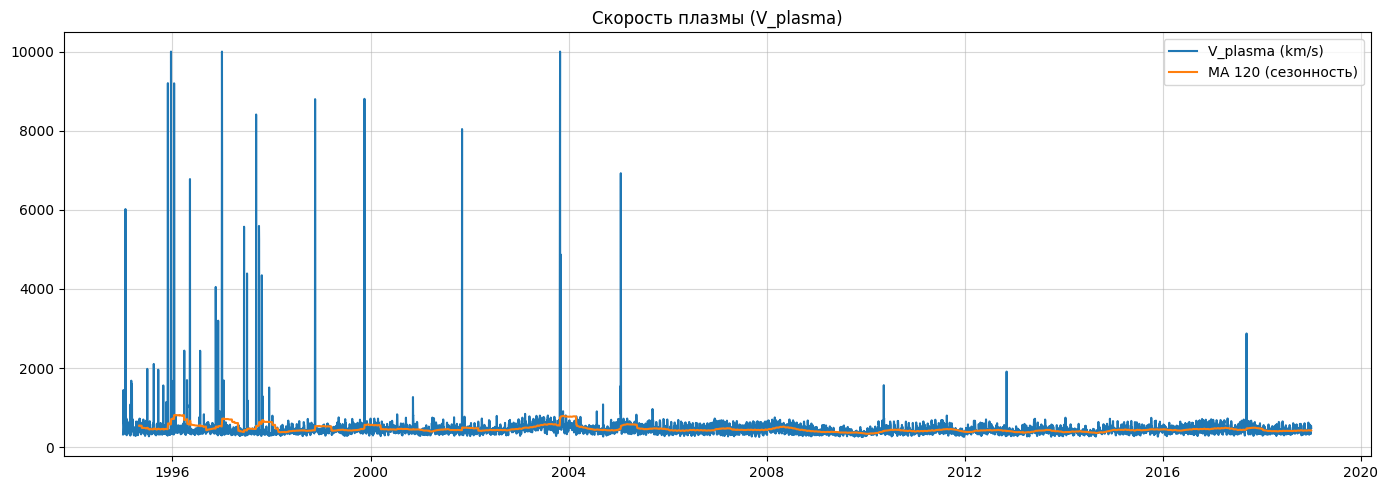

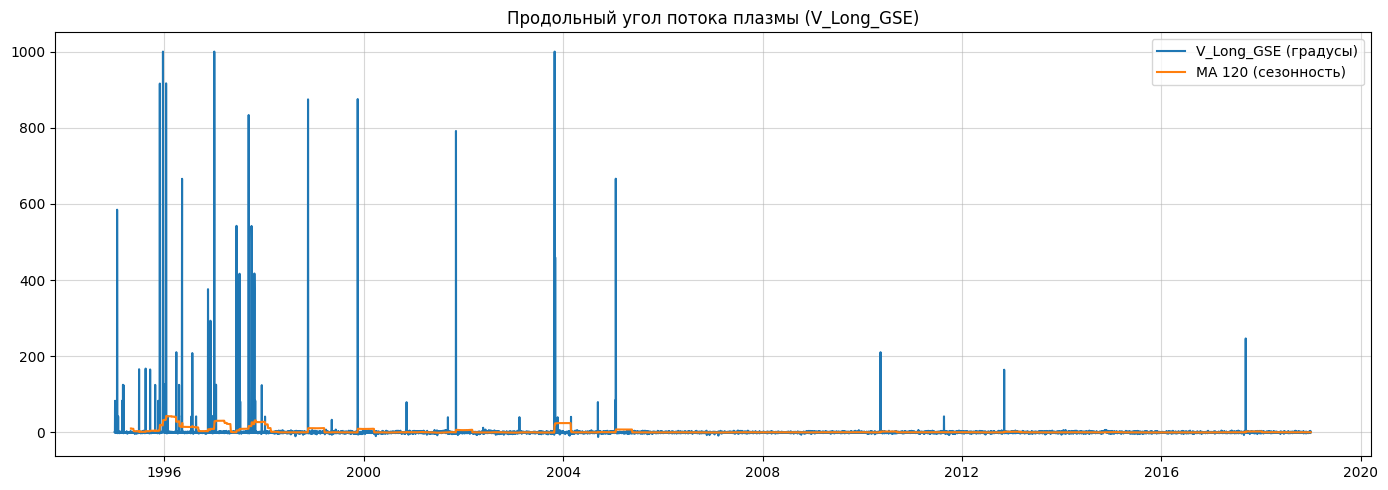

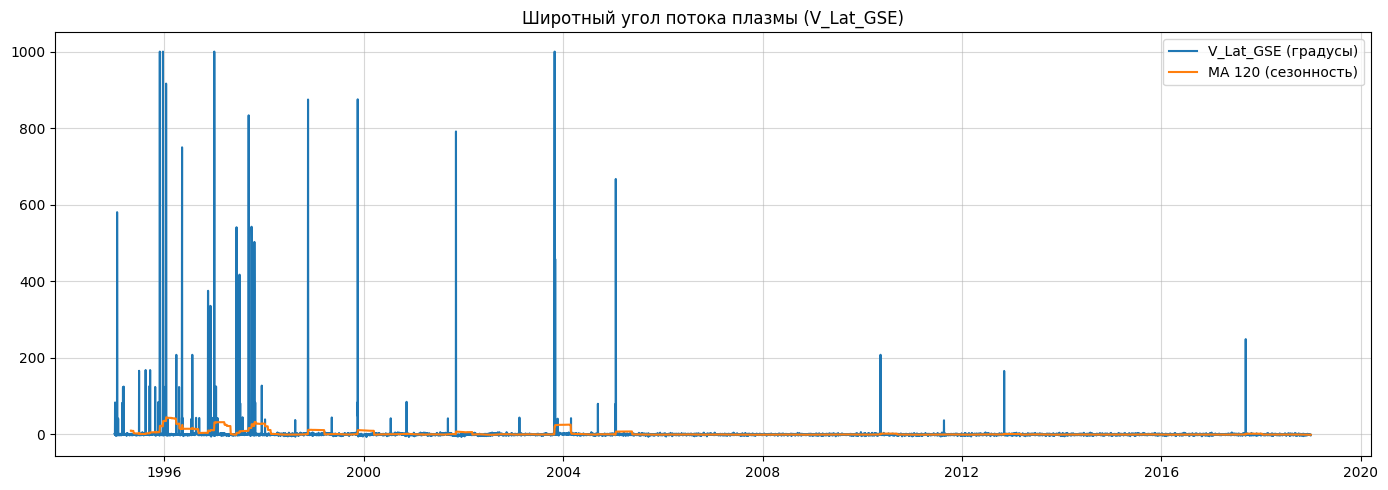

In [16]:
plasma_features = ['T_proton', 'Np_density', 'V_plasma', 'V_Long_GSE', 'V_Lat_GSE']
plasma_titles = [
    'Протонная температура (T_proton)',
    'Плотность протонов (Np_density)',
    'Скорость плазмы (V_plasma)',
    'Продольный угол потока плазмы (V_Long_GSE)',
    'Широтный угол потока плазмы (V_Lat_GSE)'
]
plasma_labels = ['T_proton (K)', 'Np_density (N/cm³)', 'V_plasma (km/s)', 'V_Long_GSE (градусы)', 'V_Lat_GSE (градусы)']

for feat, title, label in zip(plasma_features, plasma_titles, plasma_labels):
    make_ts_plot_with_ma(
        feature=daily_data[feat],
        title=title,
        label=label,
        ma_k=120,
    )

### Целевые переменные

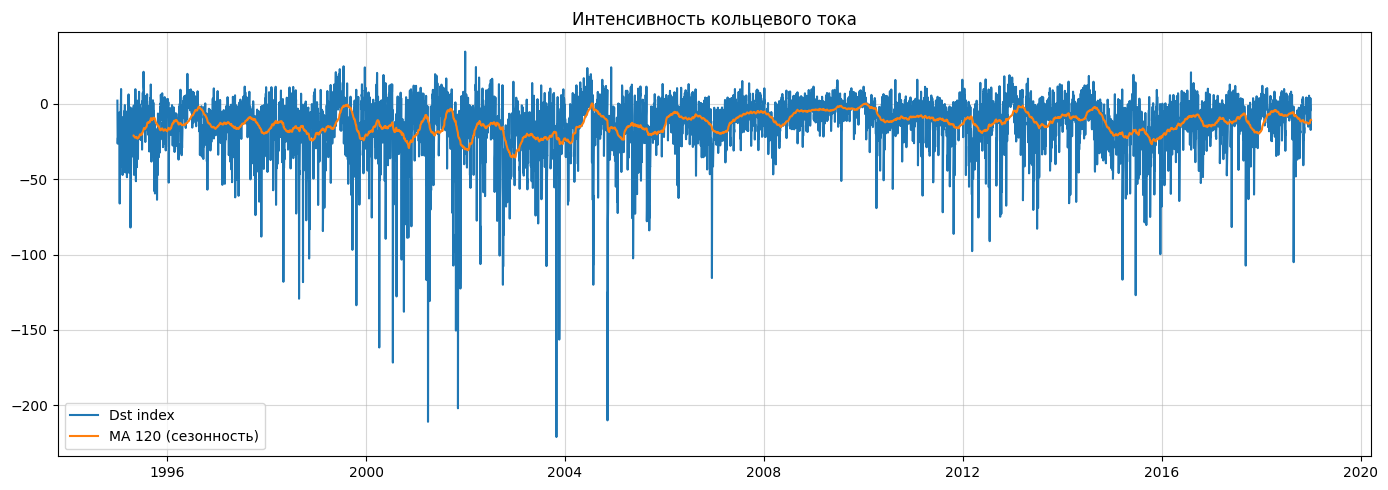

In [17]:
make_ts_plot_with_ma(
    feature=daily_data["Dst"],
    title="Интенсивность кольцевого тока",
    label="Dst index",
    ma_k=120,
)

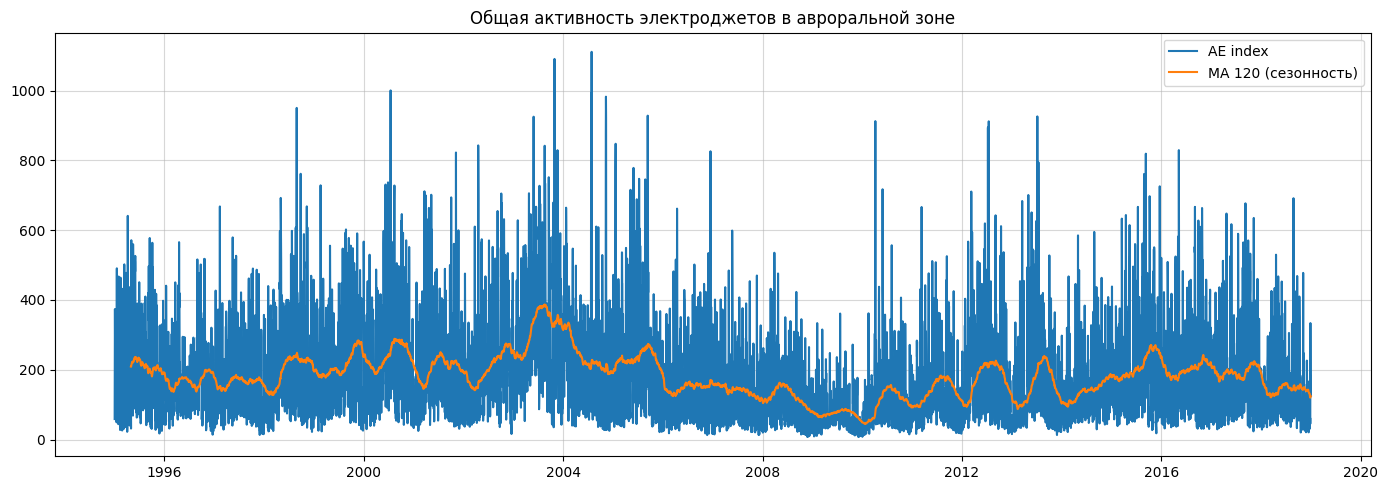

In [18]:
make_ts_plot_with_ma(
    feature=daily_data["AE"],
    title="Общая активность электроджетов в авроральной зоне",
    label="AE index",
    ma_k=120,
)

```
2019 - год низкой солнечной активности
2025 - год высокой солнечной активности
```

### Preprocessing

In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import inv_boxcox
from scipy.stats import boxcox

In [20]:
dataset.describe()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
count,210384,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,2.103840e+05,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000
mean,2006-12-31 23:30:00,1.979221,2.080122,1.874579,18.441963,109.263963,-112.295911,68.111116,3.165466e+05,30.821627,457.463357,2.709679,2.247959,-13.242243,180.439758
min,1995-01-01 00:00:00,-57.800000,-43.100000,-40.800000,0.000000,64.600000,-2452.000000,-260.000000,3.299000e+03,0.100000,228.000000,-26.900000,-17.800000,-422.000000,3.000000
25%,2000-12-31 11:45:00,-1.500000,-2.400000,-2.600000,7.000000,74.200000,-153.000000,22.000000,3.719675e+04,3.100000,354.000000,-1.700000,-2.100000,-21.000000,47.000000
50%,2006-12-31 23:30:00,0.000000,0.000000,-0.100000,17.000000,94.100000,-52.000000,44.000000,7.052950e+04,4.900000,407.000000,-0.200000,-0.700000,-10.000000,100.000000
75%,2012-12-31 11:15:00,1.400000,2.500000,2.500000,27.000000,133.100000,-21.000000,92.000000,1.307762e+05,8.100000,486.000000,1.300000,0.700000,-1.000000,245.000000
max,2018-12-31 23:00:00,999.900000,999.900000,999.900000,90.000000,999.900000,22.000000,1226.000000,9.999999e+06,999.900000,9999.000000,999.900000,999.900000,77.000000,2241.000000
std,NaN,45.103057,45.158247,43.750043,13.617466,51.154913,143.558231,68.055577,1.467536e+06,154.353747,520.345100,53.485555,54.595549,20.120794,197.759337


In [21]:
# dataset_to_preprocess.columns
# _, axis = plt.subplots(3, 1)
# axis[0].plot(dataset_to_preprocess["AL"])
# axis[1].plot(dataset_to_preprocess["AU"])
# axis[2].plot(dataset_to_preprocess["AE"])

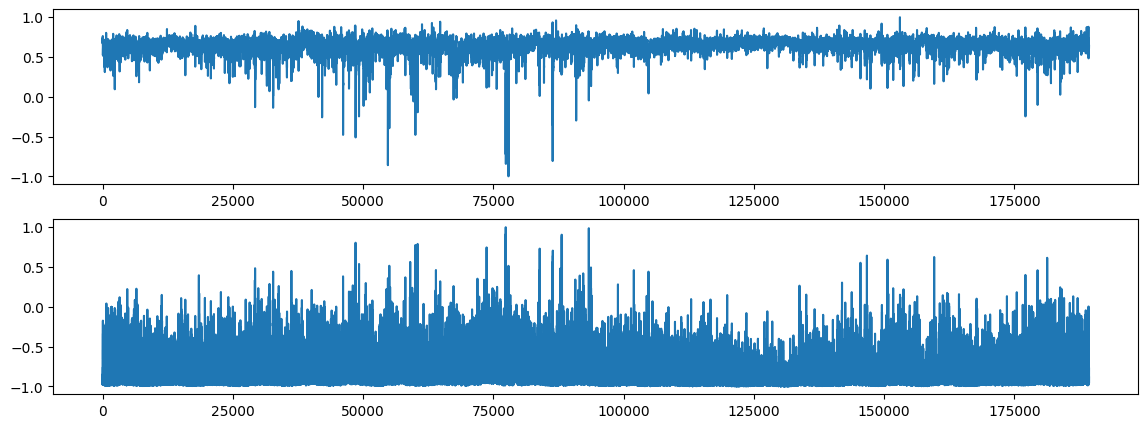

In [ ]:
dataset_to_preprocess = dataset.copy()

# 90% train, 10% test
train_size = int(len(dataset_to_preprocess) * 0.9)

train = dataset_to_preprocess.iloc[:train_size]
test = dataset_to_preprocess.iloc[train_size:]

X_train, y_train = train.drop(columns=["datetime", "Dst", "AE"]), train[["Dst", "AE"]]
X_test, y_test = test.drop(columns=["datetime", "Dst", "AE"]), test[["Dst", "AE"]]

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = MinMaxScaler(feature_range=(-1, 1))
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

_, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].plot(y_train_scaled[:, 0])
axes[1].plot(y_train_scaled[:, 1])

In [23]:
def inverse_diff(diff, first_element):
    return np.cumsum(np.concatenate([[first_element], diff]))

In [24]:
def stationarity_test(ts):
    df_test = adfuller(ts)
    out = pd.Series(df_test[0:4], index=["Test statistic", "p-value", "Lags used", "Observations"])
    for [k, v] in df_test[4].items():
        out[f"Critical value {k}"] = f"{v}:.4f"
    print(out)

In [25]:
def stationary_analysis(ts, lags=None, figsize=(14, 8)):
    stationarity_test(ts)
    if not isinstance(ts, pd.Series):
        ts = pd.Series(ts)
    plt.figure(figsize=figsize)
    layout = (5, 1)
    ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
    acf_ax = plt.subplot2grid(layout, (2, 0))
    pacf_ax = plt.subplot2grid(layout, (3, 0))
    qq_ax = plt.subplot2grid(layout, (4, 0))

    ts.plot(ax=ts_ax, color="blue", label="Or")
    ts_ax.set_title("Original")
    sm_ts_api.graphics.plot_acf(ts, lags=lags, ax=acf_ax, alpha=0.5)
    sm_ts_api.graphics.plot_pacf(ts, lags=lags, ax=pacf_ax, alpha=0.5)
    sm_api.qqplot(ts, line="s", ax=qq_ax)

    plt.tight_layout()
    plt.show()

In [44]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  # [y_window_size, 2]

        return x_window, y_window

In [112]:
X_window_size = 24*7  # 2 недели
y_window_size = 6
batch_size = 32
stride = X_window_size

train_dataset = GeomagneticDataset(
    X=X_train_scaled,
    y=y_train_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
test_dataset = GeomagneticDataset(
    X=X_test_scaled,
    y=y_test_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [97]:
?nn.LSTM

In [ ]:
class GeomagnetiModel(nn.Module):
    def __init__(
        self,
        lstm_input_size: int,
        lstm_hidden_size: int,
        lstm_num_layers: int,
        lstm_dropout: float,
        forecasts_len: int,
        *args,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.rnn_feature_extractor = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0,
            batch_first=True,
        )
        heads_hidden_size = lstm_hidden_size*2
        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )
        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        out, (ch, cn) = self.rnn_feature_extractor(x)
        x = out[:, -1, :]
        dst = self.dst_head(x)
        ae = self.ae_head(x)
        return dst, ae

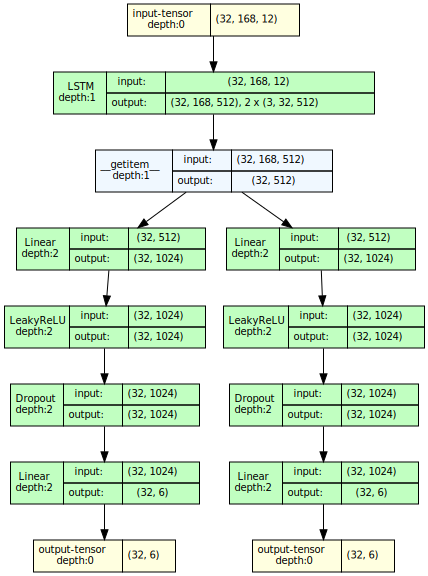

In [118]:
lr = 1e-3
lr_scheduler_step_size = 25
lr_scheduler_gamma = 0.7
EPOCHS = 200


baseline_model = GeomagnetiModel(
    lstm_input_size=12,
    lstm_hidden_size=512,
    lstm_num_layers=3,
    lstm_dropout=0.2,
    forecasts_len=y_window_size,
)
# baseline_model = GeomagnetiModel(
#     lstm_input_size=12,
#     lstm_hidden_size=500,
#     lstm_num_layers=3,
#     lstm_dropout=0.2,
#     forecasts_len=y_window_size,
# )
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(baseline_model.parameters(), lr=lr, weight_decay=0.01)
lr_scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=lr_scheduler_step_size, gamma=lr_scheduler_gamma)

graph = draw_graph(baseline_model, input_size=[batch_size, X_window_size, 12])
graph.visual_graph

In [ ]:
history = {
    "dst_loss": [],
    "ae_loss": [],
    "summary_loss": [],
    "ae": {
        "MAPE": [],
    },
    "dst": {
        "MAPE": [],
    }
}
mape_metric = torchmetrics.MeanAbsolutePercentageError().to(device)

baseline_model.to(device)

for e in range(EPOCHS):
    baseline_model.train()
    train_progress = tqdm(train_loader)
    running_history = {"dst_loss": [], "ae_loss": [], "summary_loss": [], "ae": {"MAPE": [],}, "dst": {"MAPE": [],}}
    for x, y in train_progress:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        dst_y, ae_y = y[:, :, 0], y[:, :, 1]
        dst_y_pred, ae_y_pred = baseline_model(x)

        dst_loss = loss_fn(dst_y_pred, dst_y)
        ae_loss = loss_fn(ae_y_pred, ae_y)

        loss = dst_loss + ae_loss
        loss.backward()

        dst_mape = mape_metric(dst_y_pred, dst_y).item()
        ae_mape = mape_metric(dst_y_pred, dst_y).item()

        running_history["dst"]["MAPE"].append(dst_mape)
        running_history["ae"]["MAPE"].append(ae_mape)
        # loss
        running_history["dst_loss"].append(dst_loss.item())
        running_history["ae_loss"].append(ae_loss.item())
        running_history["summary_loss"].append(loss.item())

        optimizer.step()

        train_progress.set_description(
            f"Epoch [{e+1:>3}/{EPOCHS}] Stage [TRAIN] Loss {loss.item():.3f} dst-MAPE {dst_mape:.3f} ae-MAPE {ae_mape:.3f}"
        )
    history["dst"]["MAPE"].append(np.mean(running_history["dst"]["MAPE"]))
    history["ae"]["MAPE"].append(np.mean(running_history["ae"]["MAPE"]))

    history["dst_loss"].append(np.mean(running_history["dst_loss"]))
    history["ae_loss"].append(np.mean(running_history["ae_loss"]))
    history["summary_loss"].append(np.mean(running_history["summary_loss"]))
    lr_scheduler.step()

Epoch [  1/200] Stage [TRAIN] Loss 0.021 dst-MAPE 0.063 ae-MAPE 0.063: 100%|██████████| 36/36 [00:03<00:00,  9.83it/s]
Epoch [  2/200] Stage [TRAIN] Loss 0.017 dst-MAPE 0.061 ae-MAPE 0.061: 100%|██████████| 36/36 [00:03<00:00,  9.26it/s]
Epoch [  3/200] Stage [TRAIN] Loss 0.017 dst-MAPE 0.050 ae-MAPE 0.050: 100%|██████████| 36/36 [00:04<00:00,  8.84it/s]
Epoch [  4/200] Stage [TRAIN] Loss 0.022 dst-MAPE 0.085 ae-MAPE 0.085: 100%|██████████| 36/36 [00:04<00:00,  8.44it/s]
Epoch [  5/200] Stage [TRAIN] Loss 0.017 dst-MAPE 0.065 ae-MAPE 0.065: 100%|██████████| 36/36 [00:04<00:00,  8.36it/s]
Epoch [  6/200] Stage [TRAIN] Loss 0.017 dst-MAPE 0.067 ae-MAPE 0.067: 100%|██████████| 36/36 [00:04<00:00,  8.64it/s]
Epoch [  7/200] Stage [TRAIN] Loss 0.020 dst-MAPE 0.089 ae-MAPE 0.089: 100%|██████████| 36/36 [00:03<00:00,  9.03it/s]
Epoch [  8/200] Stage [TRAIN] Loss 0.018 dst-MAPE 0.077 ae-MAPE 0.077: 100%|██████████| 36/36 [00:03<00:00,  9.42it/s]
Epoch [  9/200] Stage [TRAIN] Loss 0.020 dst-MAP

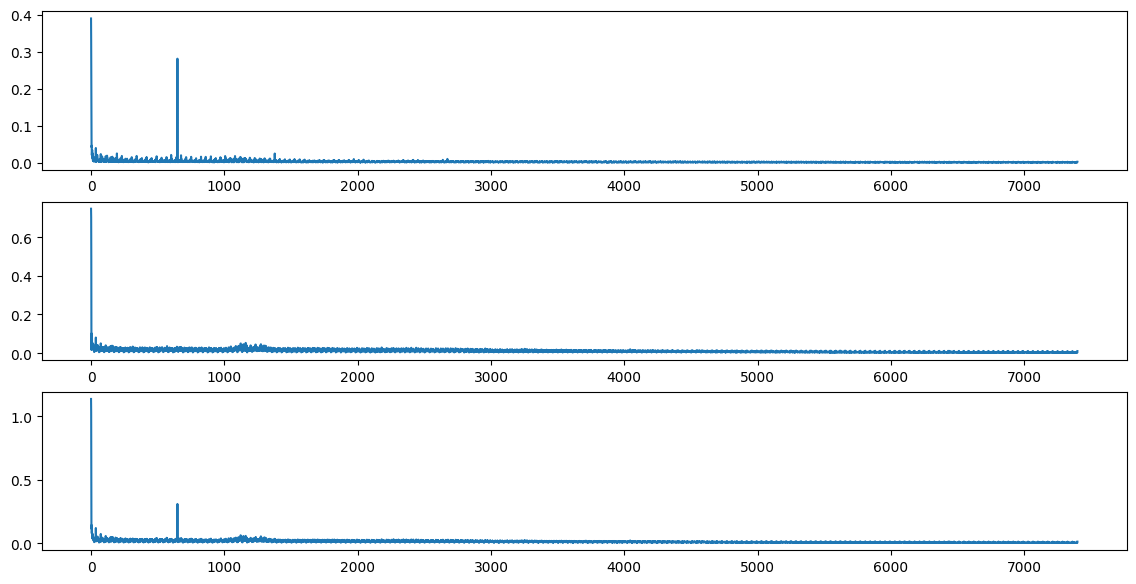

In [ ]:
_, axes = plt.subplots(3, 1, figsize=(14, 7))
axes[0].plot(history["dst_loss"])
axes[1].plot(history["ae_loss"])
axes[2].plot(history["summary_loss"])

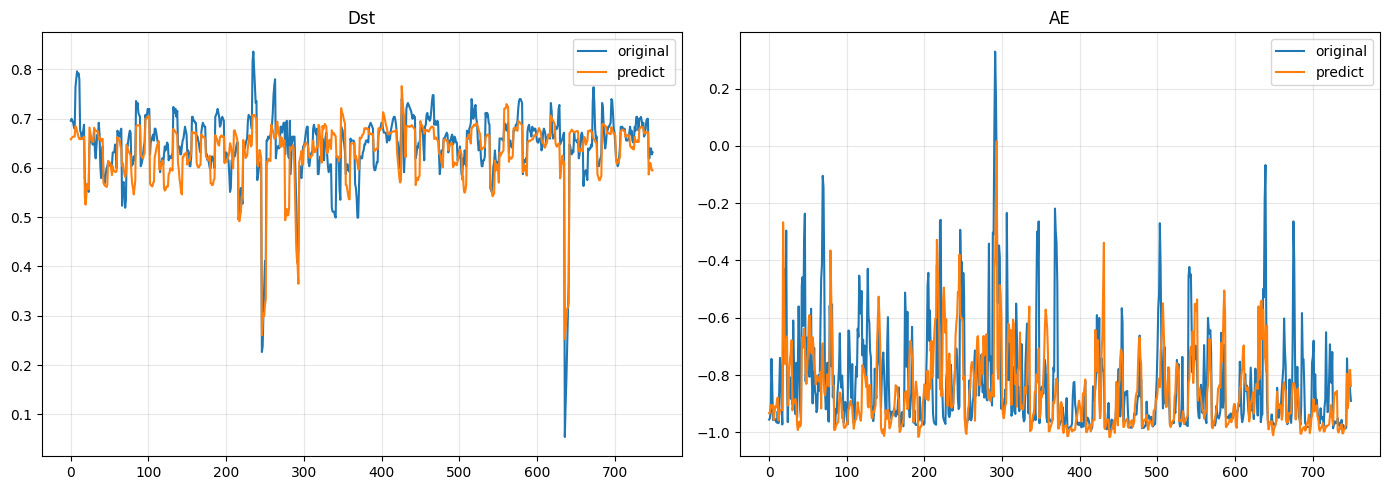

In [ ]:
dst_labels = []
ae_labels = []
dst_preds = []
ae_preds = []

with torch.no_grad():
  baseline_model.eval()
  for x, y in test_loader:
    dst_l, ae_l = y[:, :, 0], y[:, :, 1]
    for i in dst_l.flatten():
      dst_labels.append(i)
    for i in ae_l.flatten():
      ae_labels.append(i)
    x, y = x.to(device), y.to(device)

    dst_pred, ae_pred = baseline_model(x)
    for i in dst_pred.detach().cpu().flatten():
      dst_preds.append(i.item())
    for i in ae_pred.detach().cpu().flatten():
      ae_preds.append(i.item())


_, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Dst")
axes[0].plot(dst_labels, label="original")
axes[0].plot(dst_preds, label="predict")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("AE")
axes[1].plot(ae_labels, label="original")
axes[1].plot(ae_preds, label="predict")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()